# From simulated snapshots to a MOFI dynamics model

This notebook is the complete, from-zero example for MOFI. We generate the simulation input, train a model, evaluate it, and draw the analysis panels used in Figure 2.

The emphasis is on the reusable workflow rather than manuscript bookkeeping. Each section introduces one task, calls the corresponding `CytoBridge`/MOFI function, and then displays the result in a separate cell.


## What you will learn

- how a time-labelled table becomes an `AnnData` object;
- how to train and save a MOFI dynamics model;
- how to inspect quantitative evaluation metrics;
- how to plot trajectories, a potential landscape, and growth rates.

Run the notebook from top to bottom. The full Figure 2 training configuration uses 200 + 200 epochs and can take time; an existing completed result is reused automatically.


In [ ]:
from pathlib import Path
import json

from mofi_notebook import setup_notebook, suppress_live_plot_output

# Run Jupyter from the repository root. The helper selects CUDA when available.
ROOT, DEVICE, _ = setup_notebook()
print(f"Repository: {ROOT}")
print(f"Device: {DEVICE}")


## 1. Build the simulation input

`build_figure2_inputs` creates the deterministic benchmark and the matching `AnnData` object. The expression coordinates are stored in `adata.X`; observation times are stored in `adata.obs['time_point_processed']`.


In [ ]:
from CytoBridge.manuscript import build_figure2_inputs

figure2_inputs = build_figure2_inputs(repo_root=ROOT)
figure2_inputs


$ <local-path>
CSV: <local-path>
2D: (2452, 2)
3D: (2452, 3)
Merged: (2452, 5)
Counts: {0.0: 400, 0.75: 426, 1.5: 464, 2.25: 539, 3.0: 623}
$ <local-path>
Reference SHA256: 6f87e56ca9ee073ba84f10ef736a7c07dab1ff92c369053456531e878ab73eaa
Generated SHA256: 6f87e56ca9ee073ba84f10ef736a7c07dab1ff92c369053456531e878ab73eaa
Rows: 2452
Max absolute difference: 0.000e+00
PASS: regenerated Figure 2 CSV matches the retained reference.


## 2. Train the dynamics model

The fitted model, latent coordinates, velocity, and growth estimates are saved inside `adata.h5ad`. Keeping these objects together makes later analysis a normal library call rather than a separate plotting script.


In [ ]:
import time
from CytoBridge.manuscript import train_figure2

train_dir = ROOT / "results" / "figure2_mofi"
completed_manifest = train_dir / "reproduction_manifest.json"

if completed_manifest.exists() and (train_dir / "adata.h5ad").exists():
    training_seconds = None
    print("Using the completed Figure 2 training result.")
else:
    started = time.perf_counter()
    train_figure2(output_dir=train_dir, device=DEVICE, repo_root=ROOT)
    training_seconds = time.perf_counter() - started

train_dir / "adata.h5ad"


## 3. Evaluate the fitted model

The evaluation function reads the trained `AnnData` object and returns the quantitative metrics used to compare reconstructed and held-out states.


In [ ]:
from CytoBridge.manuscript import evaluate_figure2

metrics = evaluate_figure2(
    train_dir / "adata.h5ad",
    train_dir=train_dir,
    config_path=ROOT / "configs" / "training" / "simulation_figure2.yaml",
    device=DEVICE,
    training_seconds=training_seconds,
    repo_root=ROOT,
)
metrics


Reconstructing model...
Model loaded successfully.
None

--- Starting Evaluation ---
  Time Point 1.0: Wasserstein-1 Distance = 0.1585
  Time Point 1.0: TMV = 0.0099
  Time Point 2.0: Wasserstein-1 Distance = 0.1296
  Time Point 2.0: TMV = 0.0222
  Time Point 3.0: Wasserstein-1 Distance = 0.1664
  Time Point 3.0: TMV = 0.0603
  Time Point 4.0: Wasserstein-1 Distance = 0.1751
  Time Point 4.0: TMV = 0.0867


## 4. Render the dynamics panels

`render_figure2` uses the model stored in the trained `AnnData`. `sampling_seed=22` fixes the initial cells used for trajectory plotting, so repeated runs produce the same panel.


In [ ]:
from CytoBridge.manuscript import render_figure2

figure_dir = ROOT / "results" / "figure2_reproduced"
with suppress_live_plot_output():
    render_figure2(
        adata_path=train_dir / "adata.h5ad",
        output_dir=figure_dir,
        device=DEVICE,
        sampling_seed=22,
        repo_root=ROOT,
    )
figure_dir


## Potential landscape

The learned landscape summarizes the model's state-dependent dynamics.


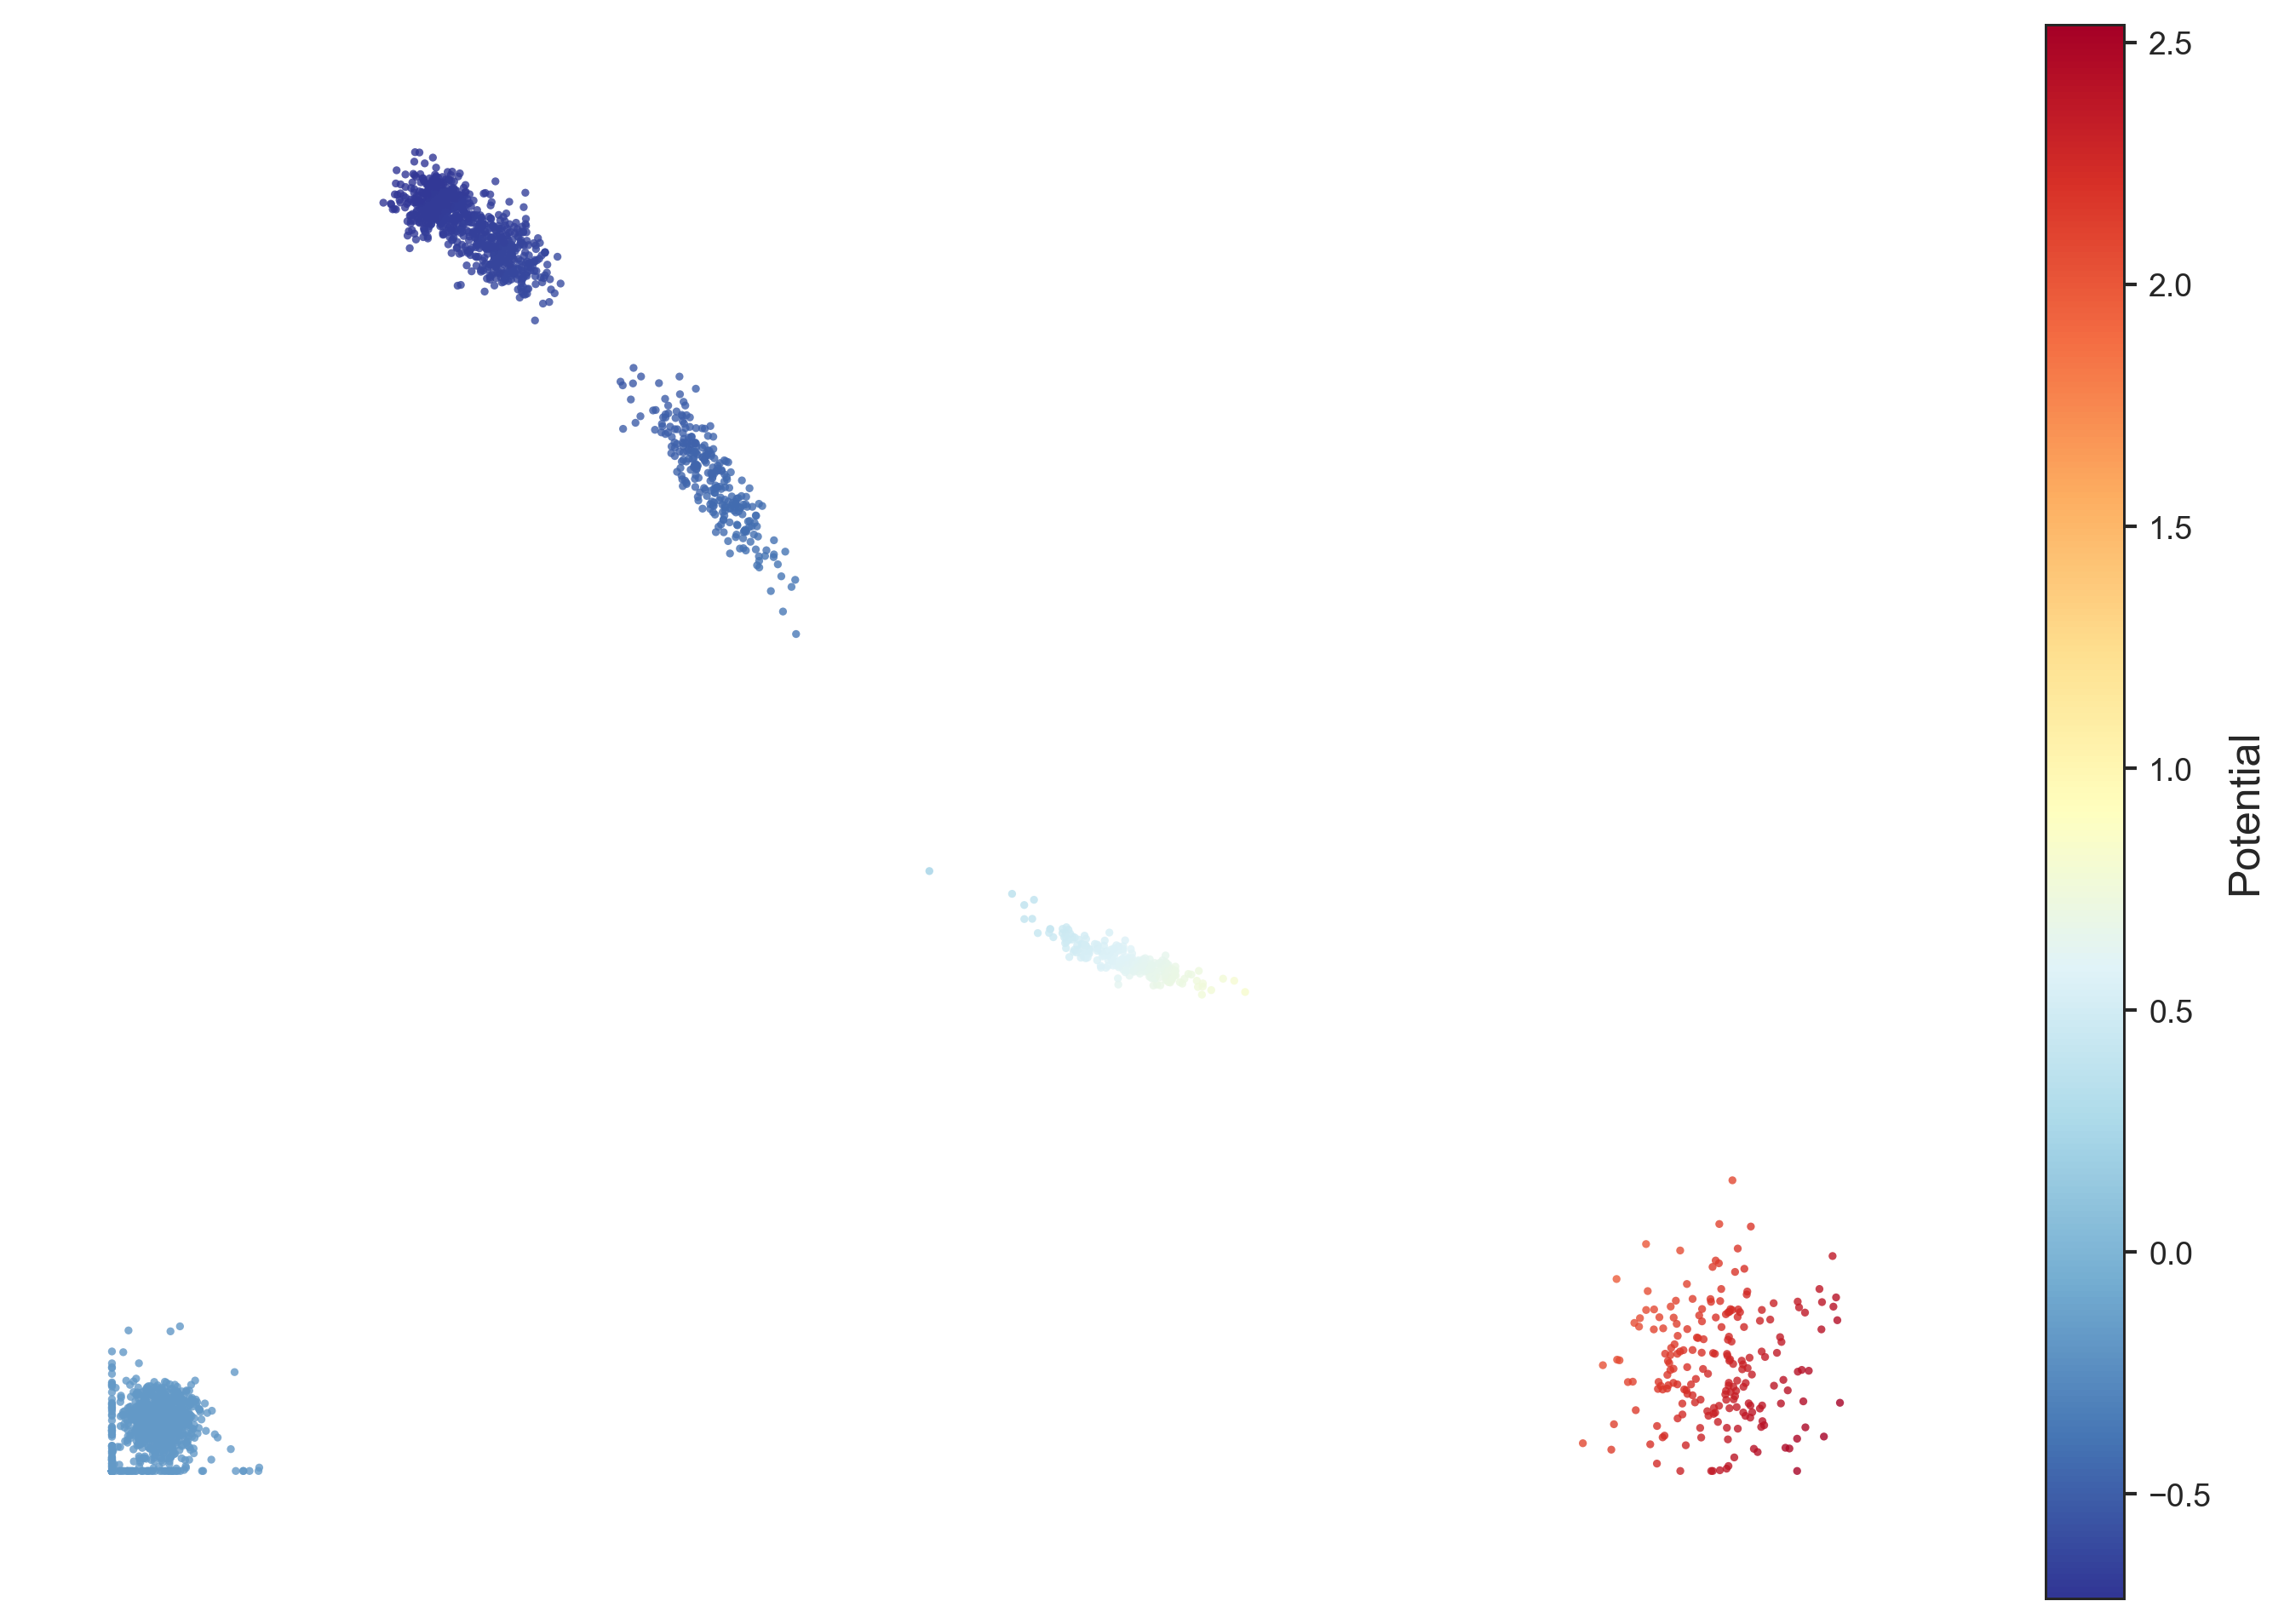

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(figure_dir / "Potential_landscape.png")


## Reconstructed trajectories

Each curve follows one sampled initial cell through the learned continuous-time dynamics.


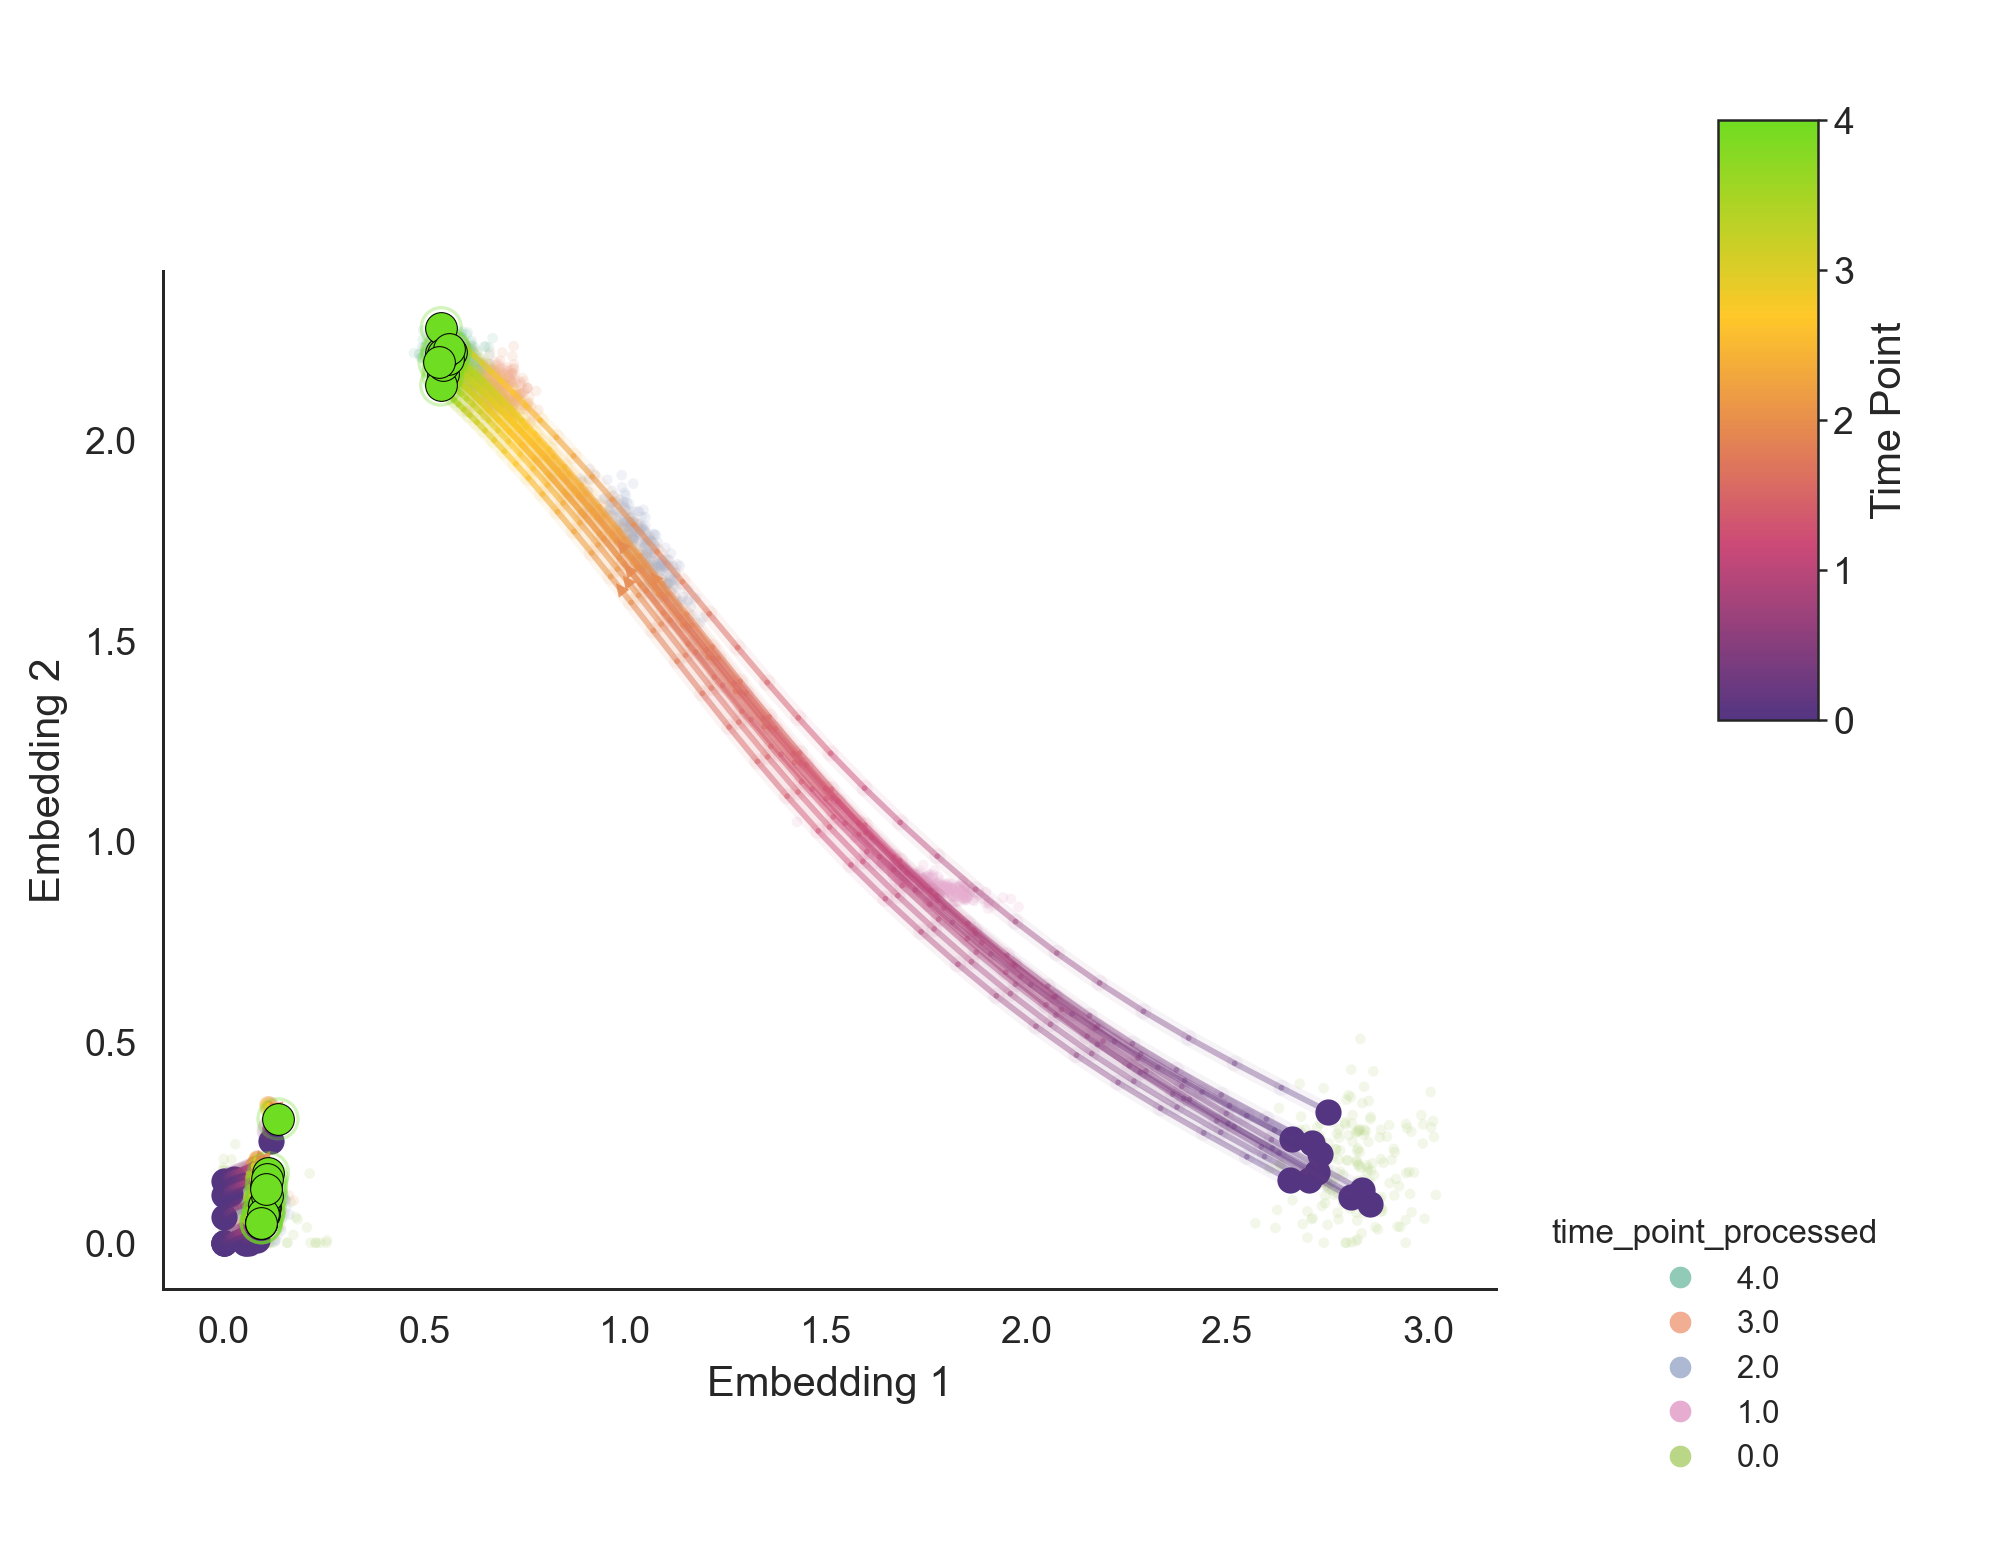

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(figure_dir / "ode_results" / "ode_trajectories_v2.png")


## Predicted growth

Warm and cool regions indicate the growth-rate structure learned by MOFI.


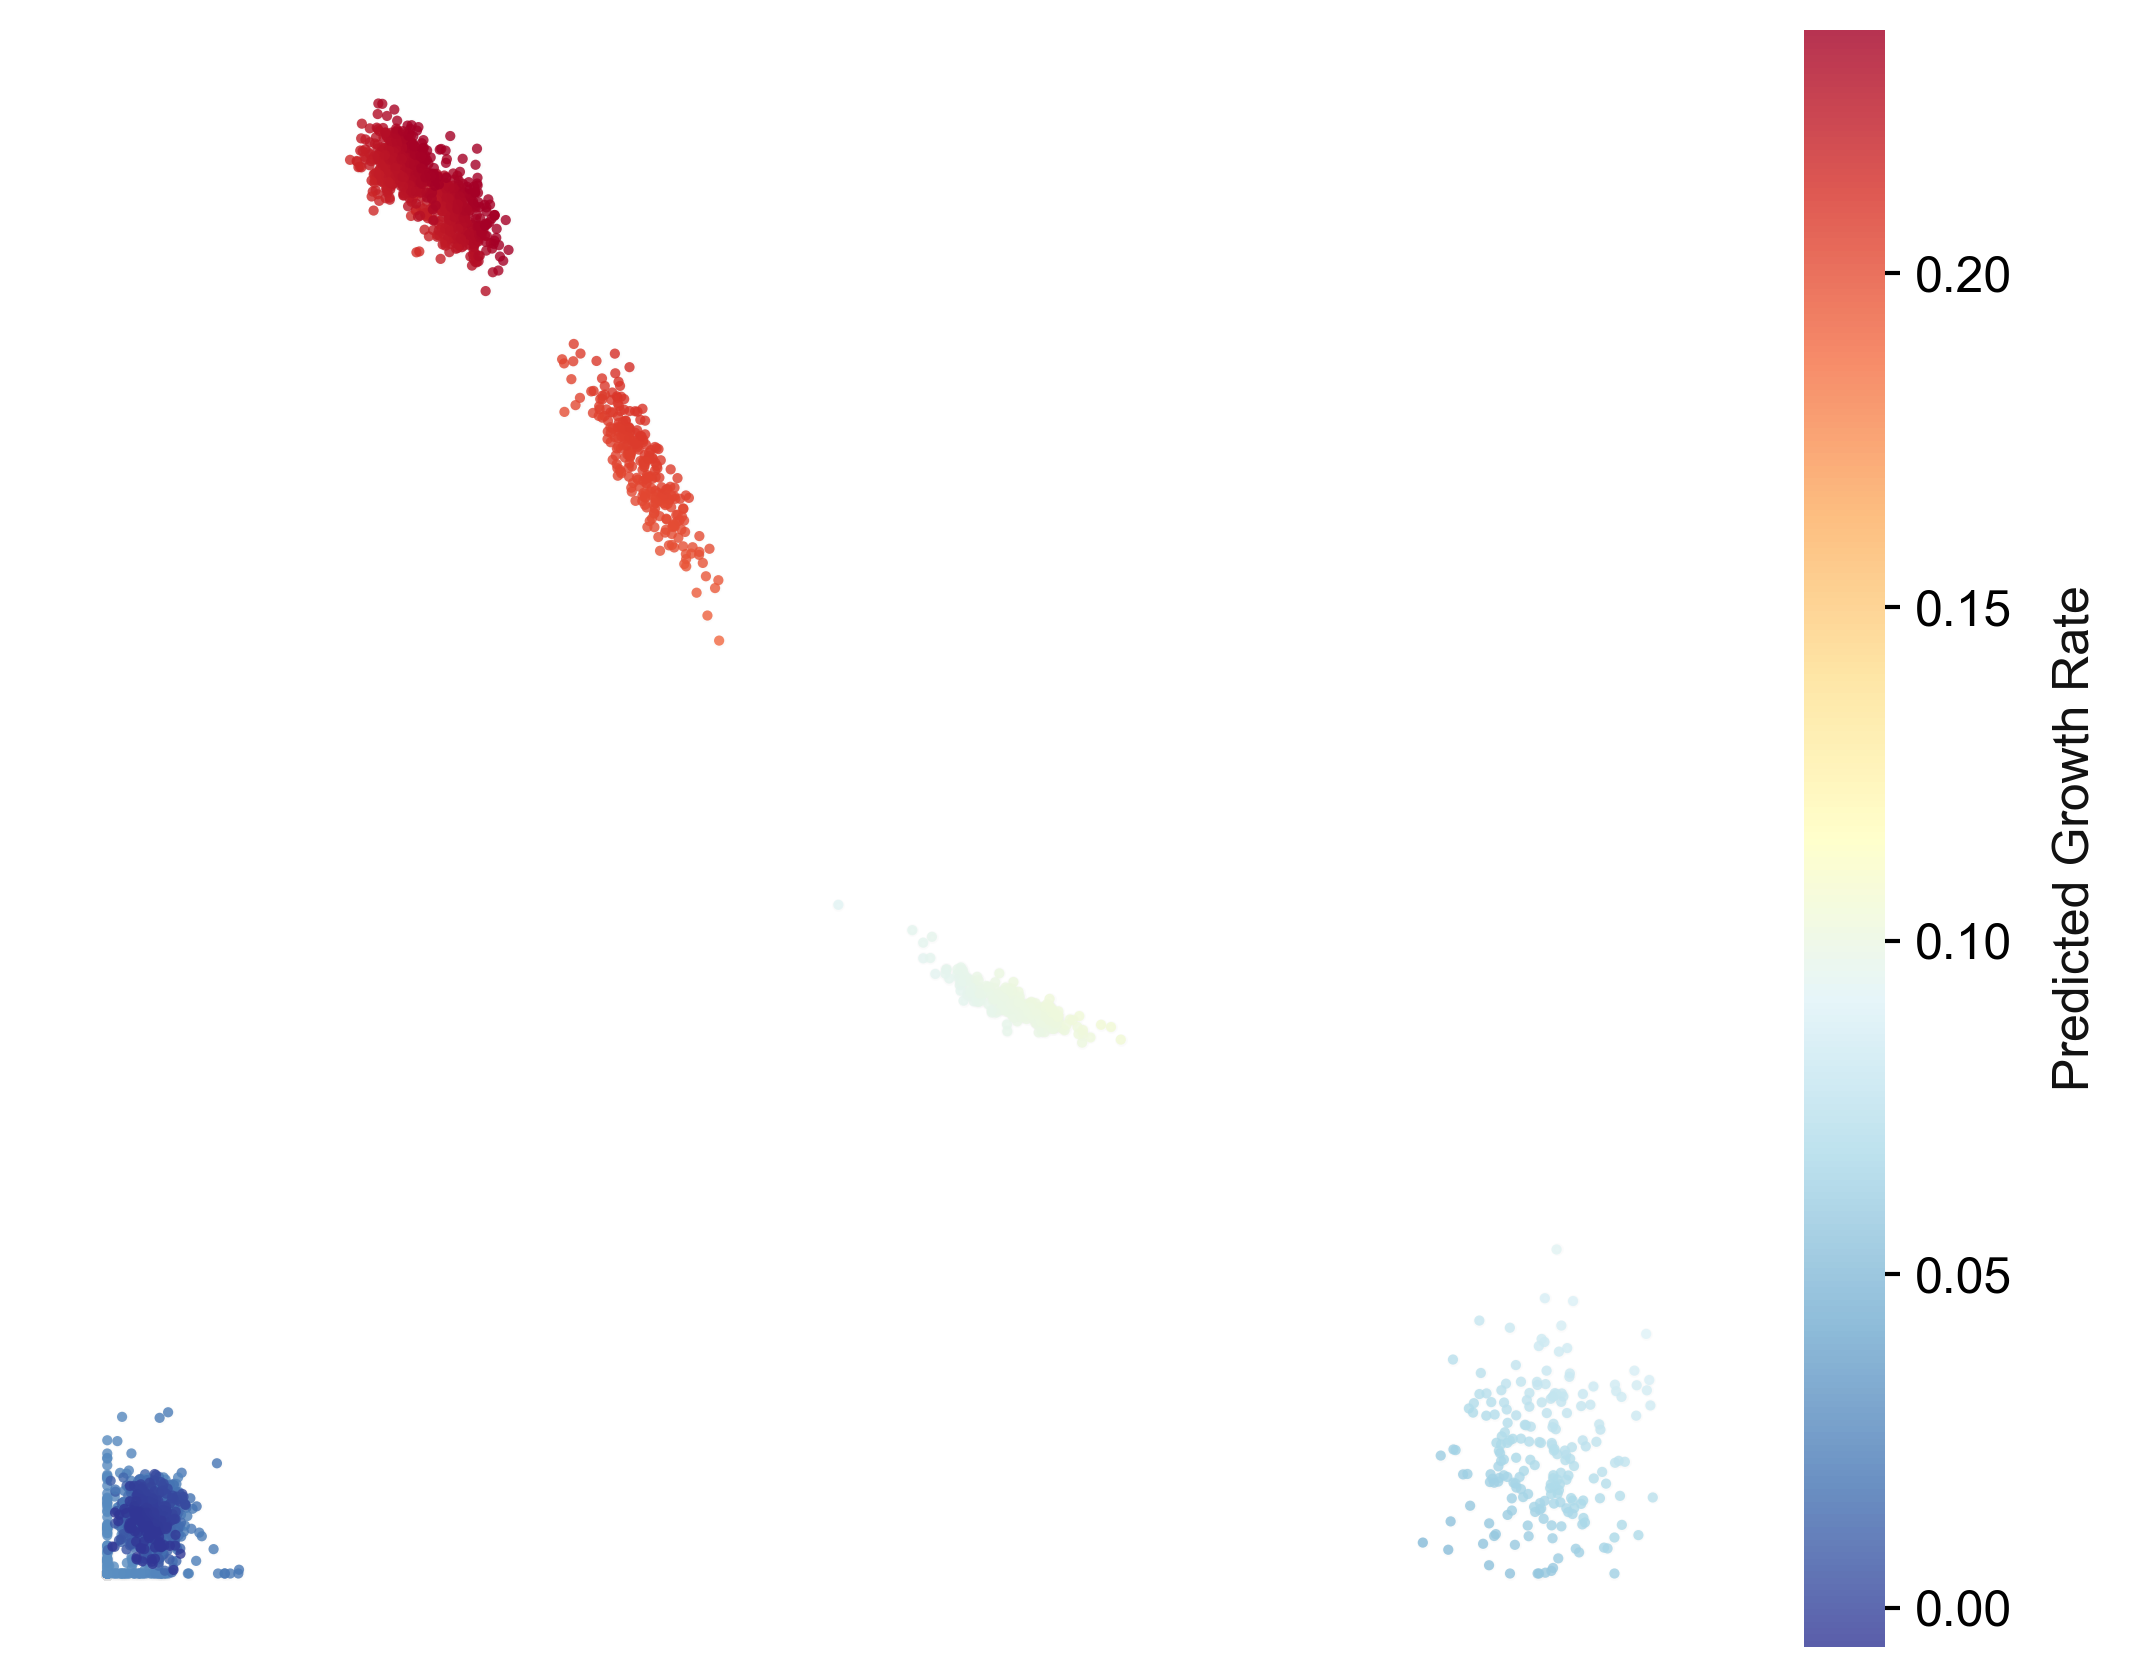

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(figure_dir / "predicted_growth.png")


## Generator growth

The known simulation growth field provides a direct reference for the model prediction above.


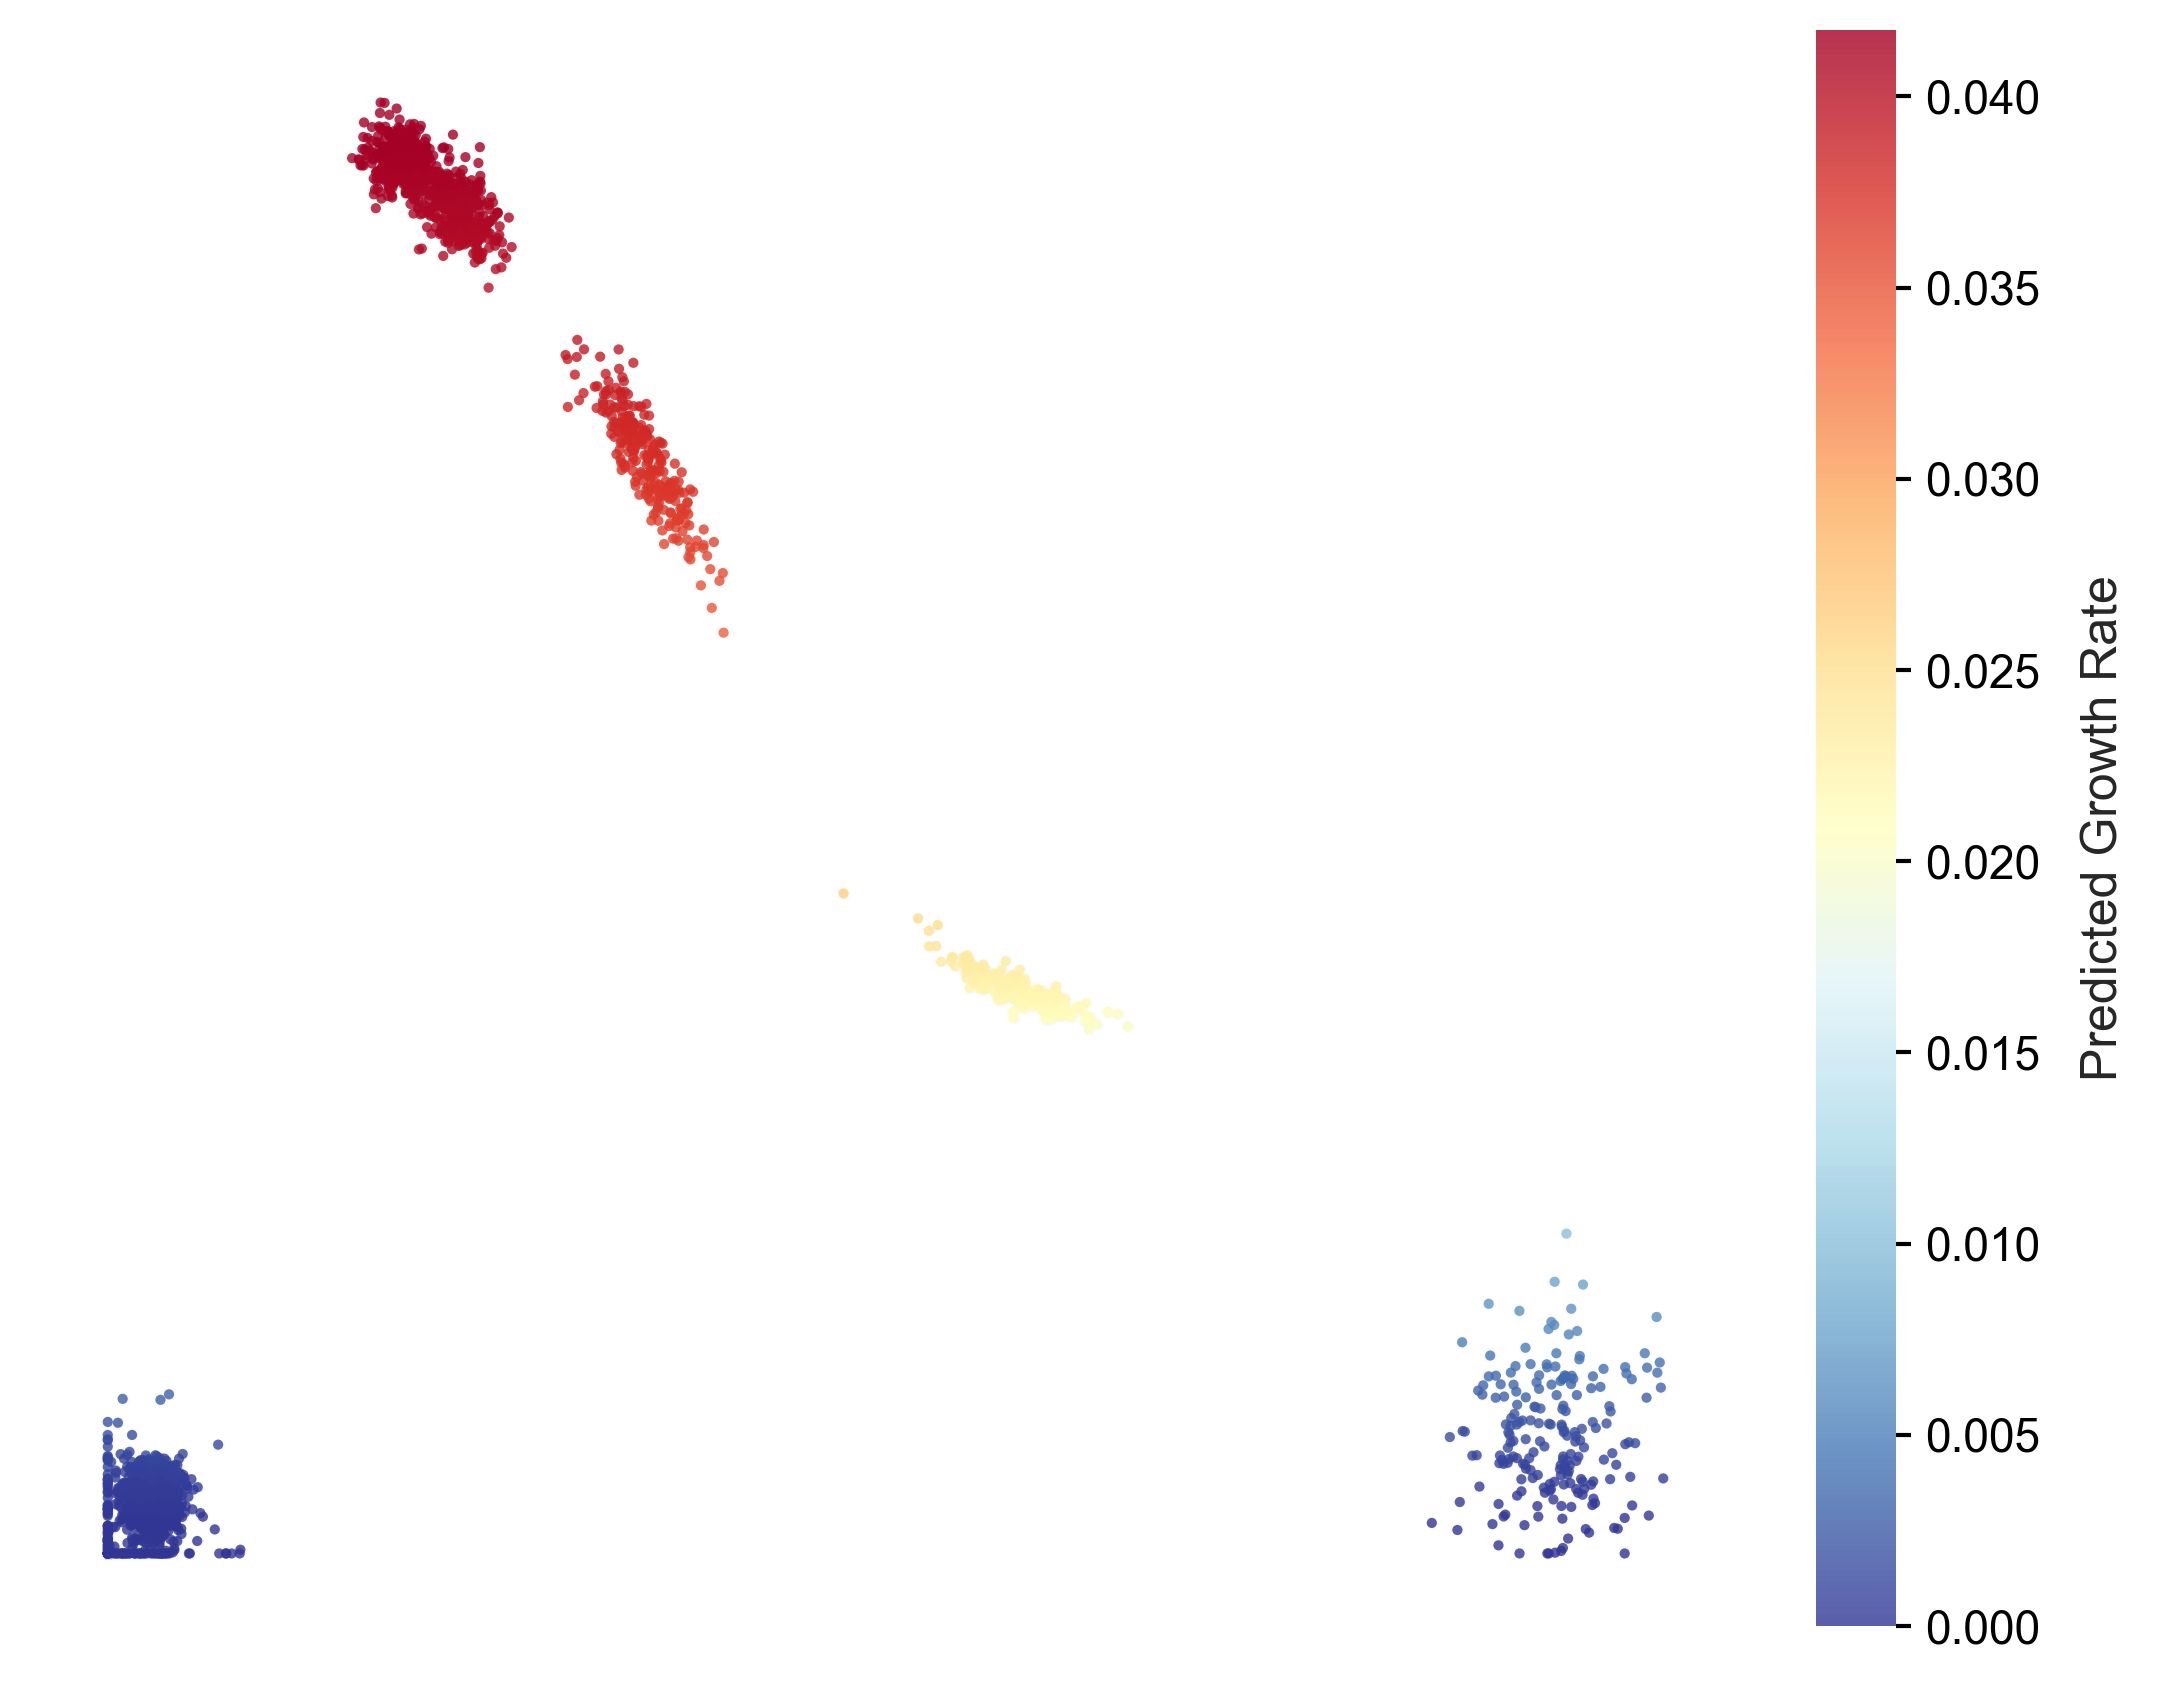

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(figure_dir / "true_growth_from_generator.png")


## Apply the workflow to your own data

The figure-specific helpers above keep the paper example concise, but the reusable workflow is the same for another single-modality or paired-modality dataset:

1. Put time labels and cell-type labels in `adata.obs`.
2. Preprocess each modality with `CytoBridge.pp.preprocess`.
3. Train the dynamics model with `CytoBridge.tl.fit` and save the returned `AnnData` object.
4. Fit or load the cross-modality map.
5. Reuse the plotting calls shown above with your own paths, marker names, perturbation targets, and time points.

```python
import scanpy as sc
import CytoBridge as cb

adata = sc.read_h5ad("my_data.h5ad")
adata = cb.pp.preprocess(
    adata,
    time_key="time",
    dim_reduction="PCA",
    normalization=True,
    log1p=True,
    select_hvg=True,
)
adata = cb.tl.fit(adata, config="ruot", device=DEVICE)
adata.write_h5ad("my_data_with_mofi_model.h5ad")
```

Start by changing only the input paths and metadata keys. Once that run works, change biological choices such as markers, source populations, perturbation scores, or displayed cell types.
